# Repairing Nearest Neighbor Heuristic

First we solve a given problem using the nearest neighbor heuristic, which is a common heuristic for TSP that can be arbitrarily bad.
Then we use the heuristic violating pairs from a WSPD of $s$ to guide a optimal repair over that subsection of the tour.
Finally we check the tour length against the optimal tour length to see how well the repair worked.

gr9882 having problems

In [1]:
from pathlib import Path
from typing import NamedTuple

# Set Numba/OpenMP thread env vars BEFORE importing any module that imports numba.

import tsplib95
import numpy as np
from tqdm.contrib.concurrent import thread_map, process_map

from utils.helpers import valid_tour, calc_tour_len_euc
from utils.wsp_heuristic import check_tour_with_wspd
from utils.nn import solve_nn_euc
from utils.repair_euc import repair_tour_euc
from utils.wspd_euc import get_wspd

SIZE_LIMIT = None
INT_DTYPE = np.int64
FLOAT_DTYPE = np.float64

TEST_RANDOM_POINTS = True

S_TEST_VALUES = (0.25, 0.5, 0.75, 1.0, 1.25, 1.5)

### The main function

In [2]:
class RepairResult(NamedTuple):
    s: float
    bad_pair_count: int
    repair_len: float
    total_pairs: int

class Result(NamedTuple):
    name: str
    size: int
    dims: int
    nn_len: float
    repair_results: list[RepairResult]
    opt_len: float

human_readable_names = {
    "name": "Problem Name",
    "size": "Number of Nodes",
    "dims": "Dimensions",
    "bad_pair_count": "Flagged Pairs",
    "total_pairs": "Total Pairs",
    "nn_len": "NN Tour Length",
    "repair_len": "Repaired Tour Length",
    "opt_len": "Optimal Tour Length",
    "s": "S Factor"
}

In [3]:
# test matching EUC_2D / EUC_3D instances
def check_tour(opt_path: Path) -> Result | None:
    try:
        tsp_path = opt_path.with_suffix("").with_suffix(".tsp")  # *.opt.tour -> *.tsp
        if not tsp_path.exists():
            raise FileNotFoundError(f"Matching .tsp file not found for {opt_path}")
        
        euc_dims = 0

        prob = tsplib95.load(str(tsp_path))
        if SIZE_LIMIT is not None and prob.dimension > SIZE_LIMIT:
            return None
        if prob.edge_weight_type not in ("EUC_2D", "EUC_3D"):
            return None
            raise ValueError(f"Unsupported edge weight type {prob.edge_weight_type} in {tsp_path}")
        elif prob.edge_weight_type == "EUC_2D":
            euc_dims = 2
        elif prob.edge_weight_type == "EUC_3D":
            euc_dims = 3

        tour_prob = tsplib95.load(str(opt_path))
        if not getattr(tour_prob, "tours", None):
            raise ValueError(f"No tours found in {opt_path}")

        opt_tour = np.array(tour_prob.tours[0], dtype=INT_DTYPE) - 1

        assert len(opt_tour) == prob.dimension, f"Tour length {len(opt_tour)} does not match problem dimension {prob.dimension}"

        #print(f"Checking {prob.name} ({prob.edge_weight_type}, n={prob.dimension})...", flush=True)

        points = np.array([prob.node_coords[i] for i in prob.get_nodes()], dtype=FLOAT_DTYPE)

        nn_tour = solve_nn_euc(points, dtype=INT_DTYPE)

        # infrastructure for randomizing points
        if TEST_RANDOM_POINTS:
            random_mapping = np.arange(len(points))
            np.random.shuffle(random_mapping)
        
        s_results: list[RepairResult] = []
        for s in S_TEST_VALUES:
            pairs, node_ranges, indices = get_wspd(points, s, int_dtype=INT_DTYPE)
            bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), nn_tour)

            node_pairs: list[tuple[np.ndarray, np.ndarray]] = []
            for idx in bad_pairs:
                a_node, b_node, _ = pairs[idx]

                a_start, a_end = node_ranges[a_node]
                b_start, b_end = node_ranges[b_node]

                A = indices[a_start:a_end]
                B = indices[b_start:b_end]

                #print(f"Bad pair: {A} (size {len(A)}) and {B} (size {len(B)})")

                node_pairs.append((A, B))

            repair_tour = nn_tour
            for A, B in node_pairs: # TODO: uncomment
                if TEST_RANDOM_POINTS:
                    A = random_mapping[A]
                    B = random_mapping[B]

                new_tour = repair_tour_euc(repair_tour, A, B, points)
                assert valid_tour(new_tour, prob.dimension), "Repaired tour is not valid"
                repair_tour = new_tour

            s_results.append(RepairResult(
                s=s,
                bad_pair_count=len(bad_pairs),
                repair_len=calc_tour_len_euc(points, repair_tour),
                total_pairs=len(pairs)
            ))

        return Result(
            name=prob.name,
            size=prob.dimension,
            dims=euc_dims,
            nn_len=calc_tour_len_euc(points, nn_tour),
            repair_results=s_results,
            opt_len=calc_tour_len_euc(points, opt_tour),
        )
    except Exception as e:
        raise RuntimeError(f"Error processing {opt_path}: {e}") from e

In [37]:
# Scan for all "*.opt.tour" files and 
search_roots = [Path("ALL_tsp")] # TSP_LIB_PATH, 
opt_tour_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.opt.tour"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            opt_tour_files.append(p)

opt_tour_files = sorted(opt_tour_files)
len(opt_tour_files)

220

In [ ]:
sifted_probs = list(filter(lambda p: p.with_suffix("").stem in tsplib_prob_names, opt_tour_files))

[PosixPath('ALL_tsp/a280.opt.tour'),
 PosixPath('ALL_tsp/ali535.opt.tour'),
 PosixPath('ALL_tsp/att48.opt.tour'),
 PosixPath('ALL_tsp/att532.opt.tour'),
 PosixPath('ALL_tsp/bayg29.opt.tour'),
 PosixPath('ALL_tsp/bays29.opt.tour'),
 PosixPath('ALL_tsp/berlin52.opt.tour'),
 PosixPath('ALL_tsp/bier127.opt.tour'),
 PosixPath('ALL_tsp/brazil58.opt.tour'),
 PosixPath('ALL_tsp/brg180.opt.tour'),
 PosixPath('ALL_tsp/burma14.opt.tour'),
 PosixPath('ALL_tsp/ch130.opt.tour'),
 PosixPath('ALL_tsp/ch150.opt.tour'),
 PosixPath('ALL_tsp/d1291.opt.tour'),
 PosixPath('ALL_tsp/d15112.opt.tour'),
 PosixPath('ALL_tsp/d1655.opt.tour'),
 PosixPath('ALL_tsp/d18512.opt.tour'),
 PosixPath('ALL_tsp/d198.opt.tour'),
 PosixPath('ALL_tsp/d2103.opt.tour'),
 PosixPath('ALL_tsp/d493.opt.tour'),
 PosixPath('ALL_tsp/d657.opt.tour'),
 PosixPath('ALL_tsp/dantzig42.opt.tour'),
 PosixPath('ALL_tsp/dsj1000.opt.tour'),
 PosixPath('ALL_tsp/eil101.opt.tour'),
 PosixPath('ALL_tsp/eil51.opt.tour'),
 PosixPath('ALL_tsp/eil76.opt.

In [44]:
# JIT warmup
dummy_points = np.random.rand(40, 2)
dummy_tour = solve_nn_euc(dummy_points, dtype=INT_DTYPE)

pairs, node_ranges, indices = get_wspd(dummy_points, 1.5, int_dtype=INT_DTYPE)
bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), dummy_tour)


# Build A, B from one valid WSPD pair (not hard-coded tiny arrays)
A = indices[node_ranges[1]['start']:node_ranges[1]['end']].astype(INT_DTYPE)
B = indices[node_ranges[2]['start']:node_ranges[2]['end']].astype(INT_DTYPE)

repair_tour_euc(dummy_tour, A, B, dummy_points), A, B

(array([ 5, 12, 17, 10, 33, 35, 11, 13,  6, 28, 25,  7,  1, 18, 21, 32,  0,
        29, 16, 39, 37, 20,  8, 31,  2,  3, 23, 26, 22,  9, 30,  4, 27, 24,
        34, 14, 19, 38, 15, 36]),
 array([ 5, 30, 12,  4, 36, 24, 17, 27, 26, 23, 10, 33, 22,  3, 35,  9,  6,
        13, 11, 28, 34, 15, 19, 25, 14, 38]),
 array([21, 18, 32,  0, 37, 29, 16, 39, 20,  2,  7,  1,  8, 31]))

In [16]:
#check_tour(opt_tour_files[122])

In [45]:
results: list[Result | None] = thread_map(check_tour, sifted_probs, max_workers=4)

  0%|          | 0/109 [00:00<?, ?it/s]

ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


Basic dual change required, but no candidate edges
Basic dual change required, but no candidate edges


ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


recomputing rownorms ...
Upperbound from x-heuristic: 109292.00
Basic dual change required, but no candidate edges


...

Hit time bound
Basic dual change required, but no candidate edges


ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


Basic dual change required, but no candidate edges
Basic dual change required, but no candidate edges


ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway
ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway
ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway
ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway
ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


Basic dual change required, but no candidate edges
Basic dual change required, but no candidate edges
Basic dual change required, but no candidate edges


### TSPLIB Names

In [36]:
search_roots = [Path("TSPLIB")]
tsp_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.tsp"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            tsp_files.append(p)

tsp_files = sorted(tsp_files)
tsplib_prob_names = [p.stem for p in tsp_files]

## Analysis of results

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['science', 'ieee', 'high-contrast'])

In [ ]:
# 1. Filter out Nones and create the initial DataFrame
valid_results = [r for r in results if r is not None]
df = pd.DataFrame(valid_results)

# 2. Explode the list of RepairResults so each one gets its own row
df = df.explode('repair_results').reset_index(drop=True)

# 3. Expand the RepairResult NamedTuples into separate columns
# (Since NamedTuples act like standard tuples, we convert them to dicts first)
repair_df = pd.DataFrame(
    df['repair_results'].apply(lambda x: x._asdict() if pd.notnull(x) else {})
    .tolist(), 
    index=df.index
)

# 4. Drop the old nested column and join the new flat columns
df = df.drop(columns=['repair_results']).join(repair_df)
df.to_csv("nn_repair_results.csv", index=False)

In [60]:
df = pd.read_csv("nn_repair_results.csv")

In [74]:
df["normed_nn_len"] = df["nn_len"] / df["opt_len"]
df["normed_repair_len"] = df["repair_len"] / df["opt_len"]
df["optimality_reduction"] = 1 - ((df["normed_repair_len"] - 1) / (df["normed_nn_len"] - 1))
df["random_optimality_reduction"] = 1 - ((df["random_repair_len"] / df["opt_len"] - 1) / (df["normed_nn_len"] - 1))
df["optimality_reduction_per_bad_pair"] = df["optimality_reduction"] / df["bad_pair_count"]
df["optimality_reduction_per_total_pair"] = df["optimality_reduction"] / df["total_pairs"]
df["normed_nn_repair_diff"] = df["normed_nn_len"] - df["normed_repair_len"]
df["bad_pair_fraction"] = df["bad_pair_count"] / df["total_pairs"]
df

,name,size,dims,nn_len,opt_len,s,bad_pair_count,repair_len,total_pairs,random_repair_len,normed_nn_len,normed_repair_len,optimality_reduction,optimality_reduction_per_bad_pair,optimality_reduction_per_total_pair,normed_nn_repair_diff,bad_pair_fraction,random_optimality_reduction
0,Tnm100,100,2,1574837.0,1398070.0,0.25,1,1521412.0,230,NaN,1.126436,1.088223,0.302234,0.302234,1.314061e-03,0.038213,0.004348,NaN
1,Tnm100,100,2,1574837.0,1398070.0,0.50,0,1574837.0,315,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
2,Tnm100,100,2,1574837.0,1398070.0,0.75,0,1574837.0,373,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
3,Tnm100,100,2,1574837.0,1398070.0,1.00,0,1574837.0,490,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
4,Tnm100,100,2,1574837.0,1398070.0,1.25,0,1574837.0,585,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,xvb13584,13584,2,47193.0,37084.0,0.50,6,47166.0,27738,NaN,1.272597,1.271869,0.002671,0.000445,9.628983e-08,0.000728,0.000216,NaN
1118,xvb13584,13584,2,47193.0,37084.0,0.75,0,47193.0,37223,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
1119,xvb13584,13584,2,47193.0,37084.0,1.00,0,47193.0,49503,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
1120,xvb13584,13584,2,47193.0,37084.0,1.25,0,47193.0,62775,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN


In [75]:
df_drop_solved = df[df["nn_len"] > df["opt_len"]]
df_drop_solved

,name,size,dims,nn_len,opt_len,s,bad_pair_count,repair_len,total_pairs,random_repair_len,normed_nn_len,normed_repair_len,optimality_reduction,optimality_reduction_per_bad_pair,optimality_reduction_per_total_pair,normed_nn_repair_diff,bad_pair_fraction,random_optimality_reduction
0,Tnm100,100,2,1574837.0,1398070.0,0.25,1,1521412.0,230,NaN,1.126436,1.088223,0.302234,0.302234,1.314061e-03,0.038213,0.004348,NaN
1,Tnm100,100,2,1574837.0,1398070.0,0.50,0,1574837.0,315,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
2,Tnm100,100,2,1574837.0,1398070.0,0.75,0,1574837.0,373,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
3,Tnm100,100,2,1574837.0,1398070.0,1.00,0,1574837.0,490,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
4,Tnm100,100,2,1574837.0,1398070.0,1.25,0,1574837.0,585,NaN,1.126436,1.126436,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,xvb13584,13584,2,47193.0,37084.0,0.50,6,47166.0,27738,NaN,1.272597,1.271869,0.002671,0.000445,9.628983e-08,0.000728,0.000216,NaN
1118,xvb13584,13584,2,47193.0,37084.0,0.75,0,47193.0,37223,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
1119,xvb13584,13584,2,47193.0,37084.0,1.00,0,47193.0,49503,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN
1120,xvb13584,13584,2,47193.0,37084.0,1.25,0,47193.0,62775,NaN,1.272597,1.272597,0.000000,NaN,0.000000e+00,0.000000,0.000000,NaN


In [76]:
df_tsplib = df_drop_solved[df_drop_solved['name'].isin(tsplib_prob_names)]
df_tsplib

,name,size,dims,nn_len,opt_len,s,bad_pair_count,repair_len,total_pairs,random_repair_len,normed_nn_len,normed_repair_len,optimality_reduction,optimality_reduction_per_bad_pair,optimality_reduction_per_total_pair,normed_nn_repair_diff,bad_pair_fraction,random_optimality_reduction
300,a280,280,2,3157.0,2579.0,0.25,5,3155.0,678,3157.0,1.224118,1.223342,0.003460,0.000692,5.103551e-06,0.000775,0.007375,0.0
301,a280,280,2,3157.0,2579.0,0.50,0,3157.0,939,3157.0,1.224118,1.224118,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
302,a280,280,2,3157.0,2579.0,0.75,0,3157.0,1306,3157.0,1.224118,1.224118,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
303,a280,280,2,3157.0,2579.0,1.00,0,3157.0,1757,3157.0,1.224118,1.224118,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
304,a280,280,2,3157.0,2579.0,1.25,0,3157.0,2055,3157.0,1.224118,1.224118,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,vm1748,1748,2,408101.0,336555.0,0.50,1,408075.0,3948,408101.0,1.212583,1.212506,0.000363,0.000363,9.204726e-08,0.000077,0.000253,0.0
1046,vm1748,1748,2,408101.0,336555.0,0.75,0,408101.0,5152,408101.0,1.212583,1.212583,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
1047,vm1748,1748,2,408101.0,336555.0,1.00,0,408101.0,6706,408101.0,1.212583,1.212583,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0
1048,vm1748,1748,2,408101.0,336555.0,1.25,0,408101.0,8077,408101.0,1.212583,1.212583,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.0


### Guaranteed optimality reduction

In [77]:
df_15 = df_tsplib[df_tsplib['s'] == 1.5]
df_15.set_index("name", inplace=True)

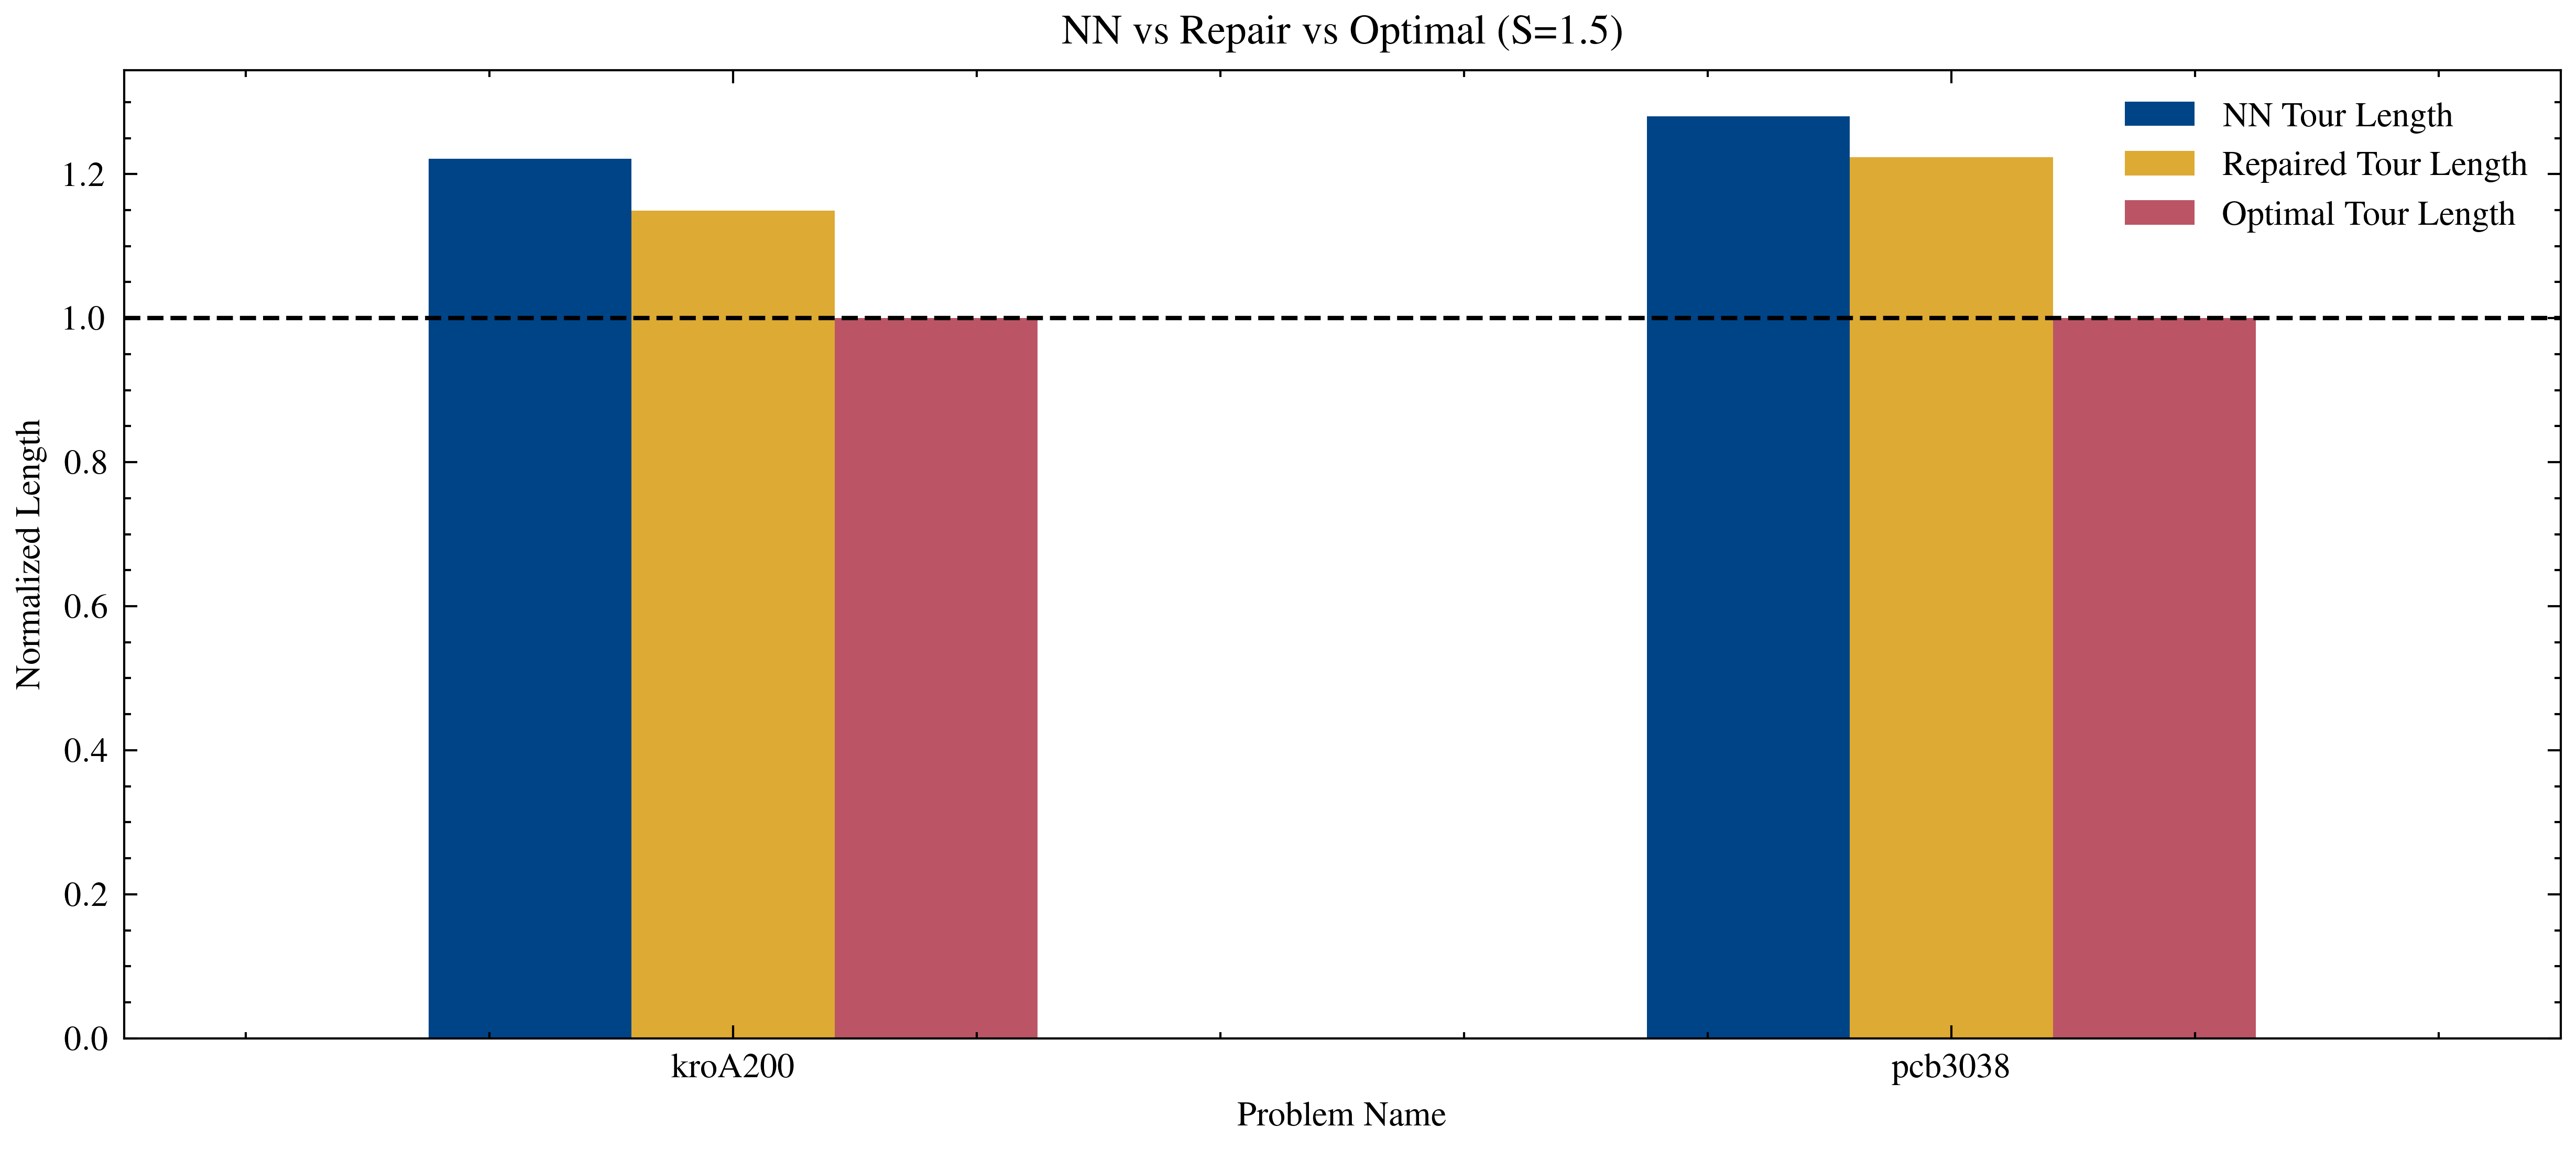

In [78]:
# drop those with no bad pairs
bad_count_df = df_15[df_15.bad_pair_count > 0].copy()

pct_df = bad_count_df[["nn_len", "repair_len", "opt_len"]].div(bad_count_df["opt_len"], axis=0)

pct_df["name"] = bad_count_df.index
pct_df.set_index("name", inplace=True)
ax = pct_df.rename(columns=human_readable_names).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_xlabel("Problem Name")
ax.set_ylabel("Normalized Length")
ax.set_title("NN vs Repair vs Optimal (S=1.5)")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)


In [79]:
# optimality reduction

bad_count_df["optimality_reduction"]

name
kroA200    0.323987
pcb3038    0.204345
Name: optimality_reduction, dtype: float64

### Ablation of $s$

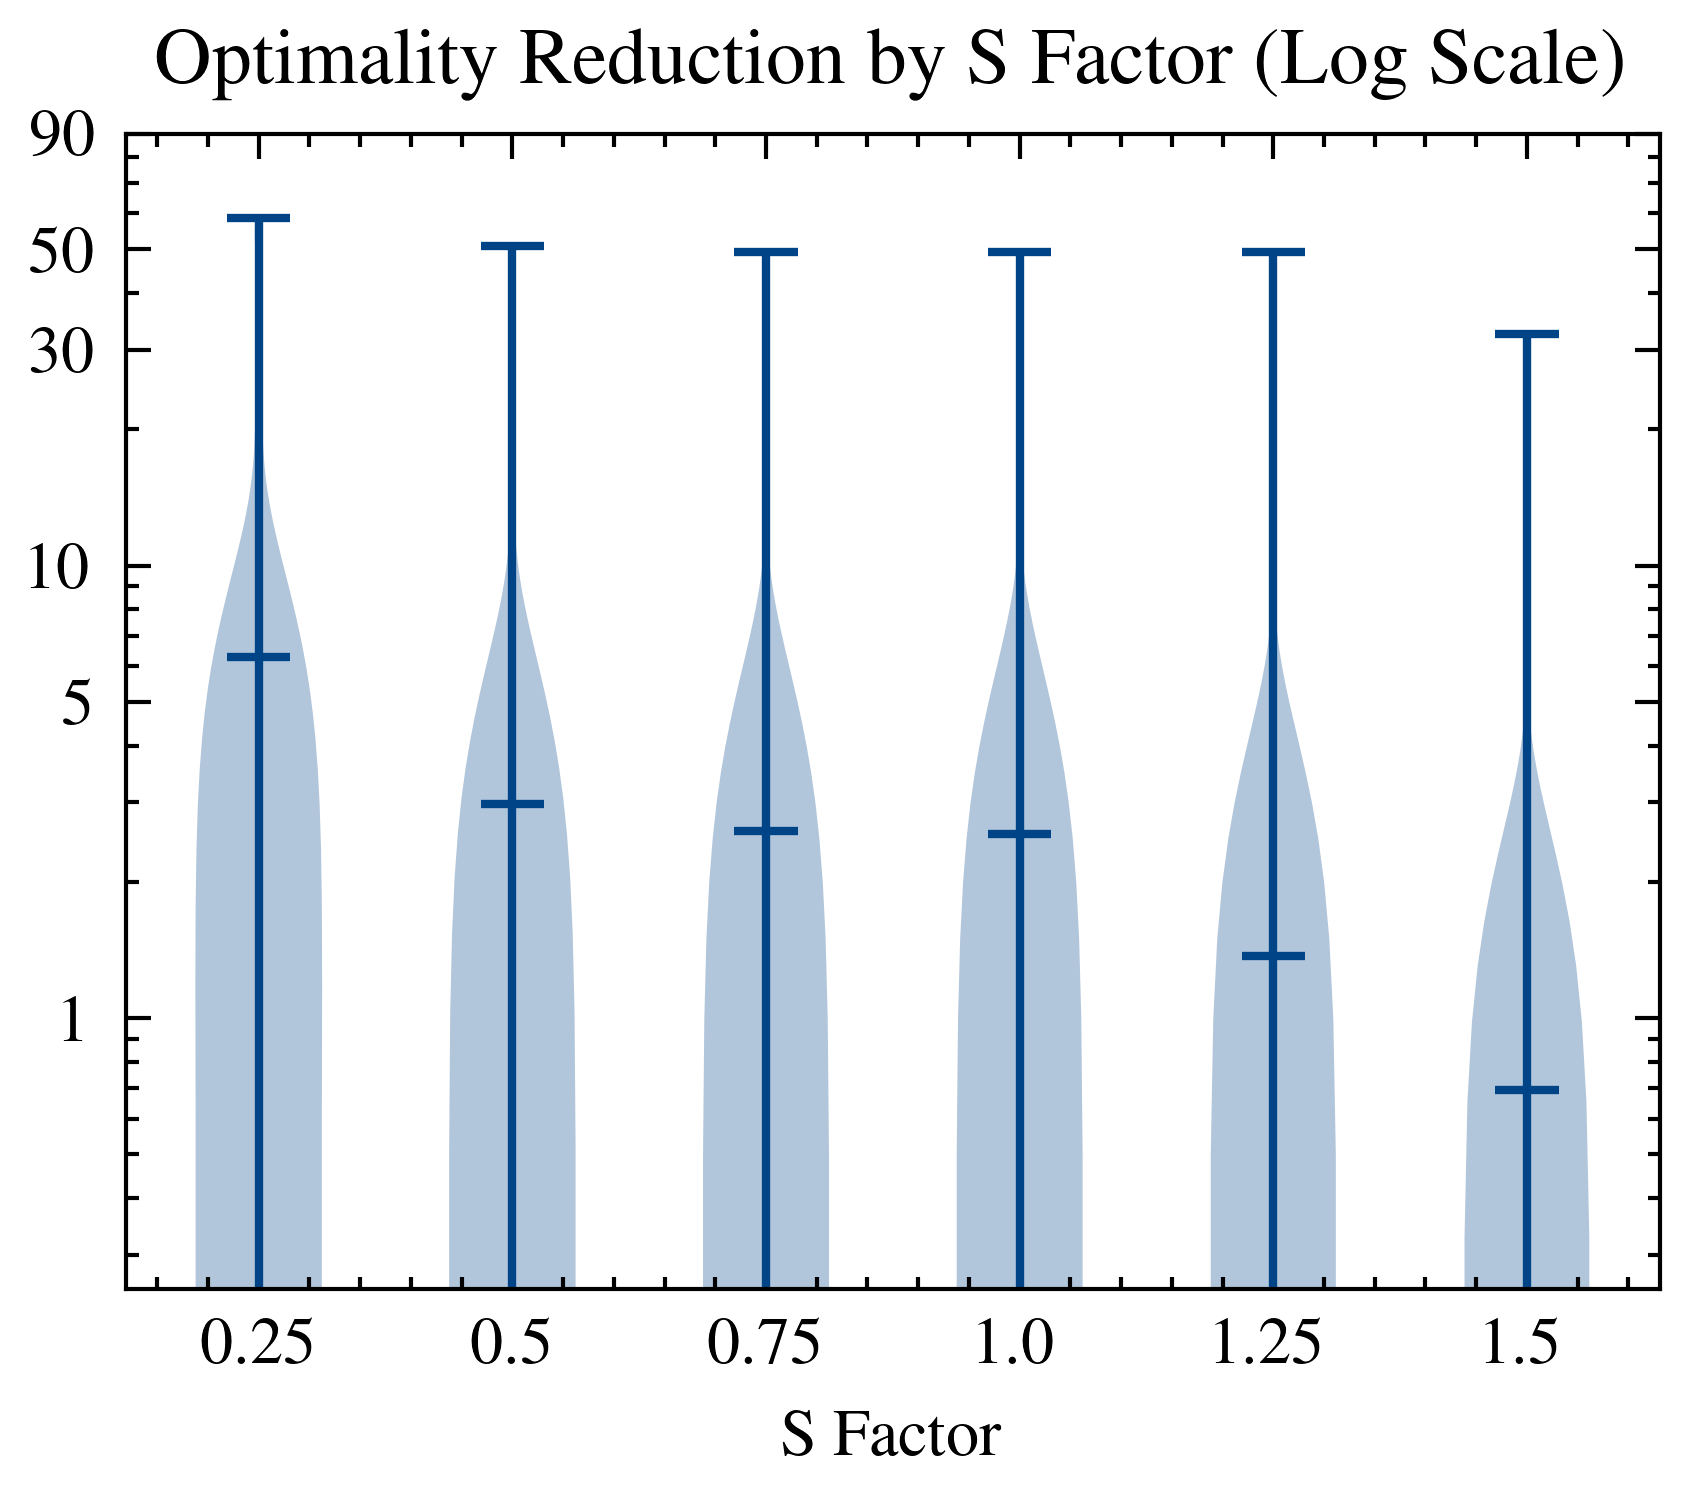

In [80]:
#sns.violinplot(data=df_tsplib, x="s", y="optimality_reduction", log_scale=True)

#mpl version
fig, ax = plt.subplots()
vplot = ax.violinplot(
    [df_tsplib[df_tsplib["s"] == s]["optimality_reduction"].dropna() for s in S_TEST_VALUES],
    showmeans=True,
)
ax.set_yscale("log")
ax.set_xlabel("S Factor")
ax.set_xticks(ticks=np.arange(1, len(S_TEST_VALUES) + 1), labels=S_TEST_VALUES)
ax.set_title("Optimality Reduction by S Factor (Log Scale)")
ax.set_yticks([0.01, 0.05, 0.1, 0.3, 0.5, 0.9], labels=["1%", "5%", "10%", "30%", "50%", "90%"])

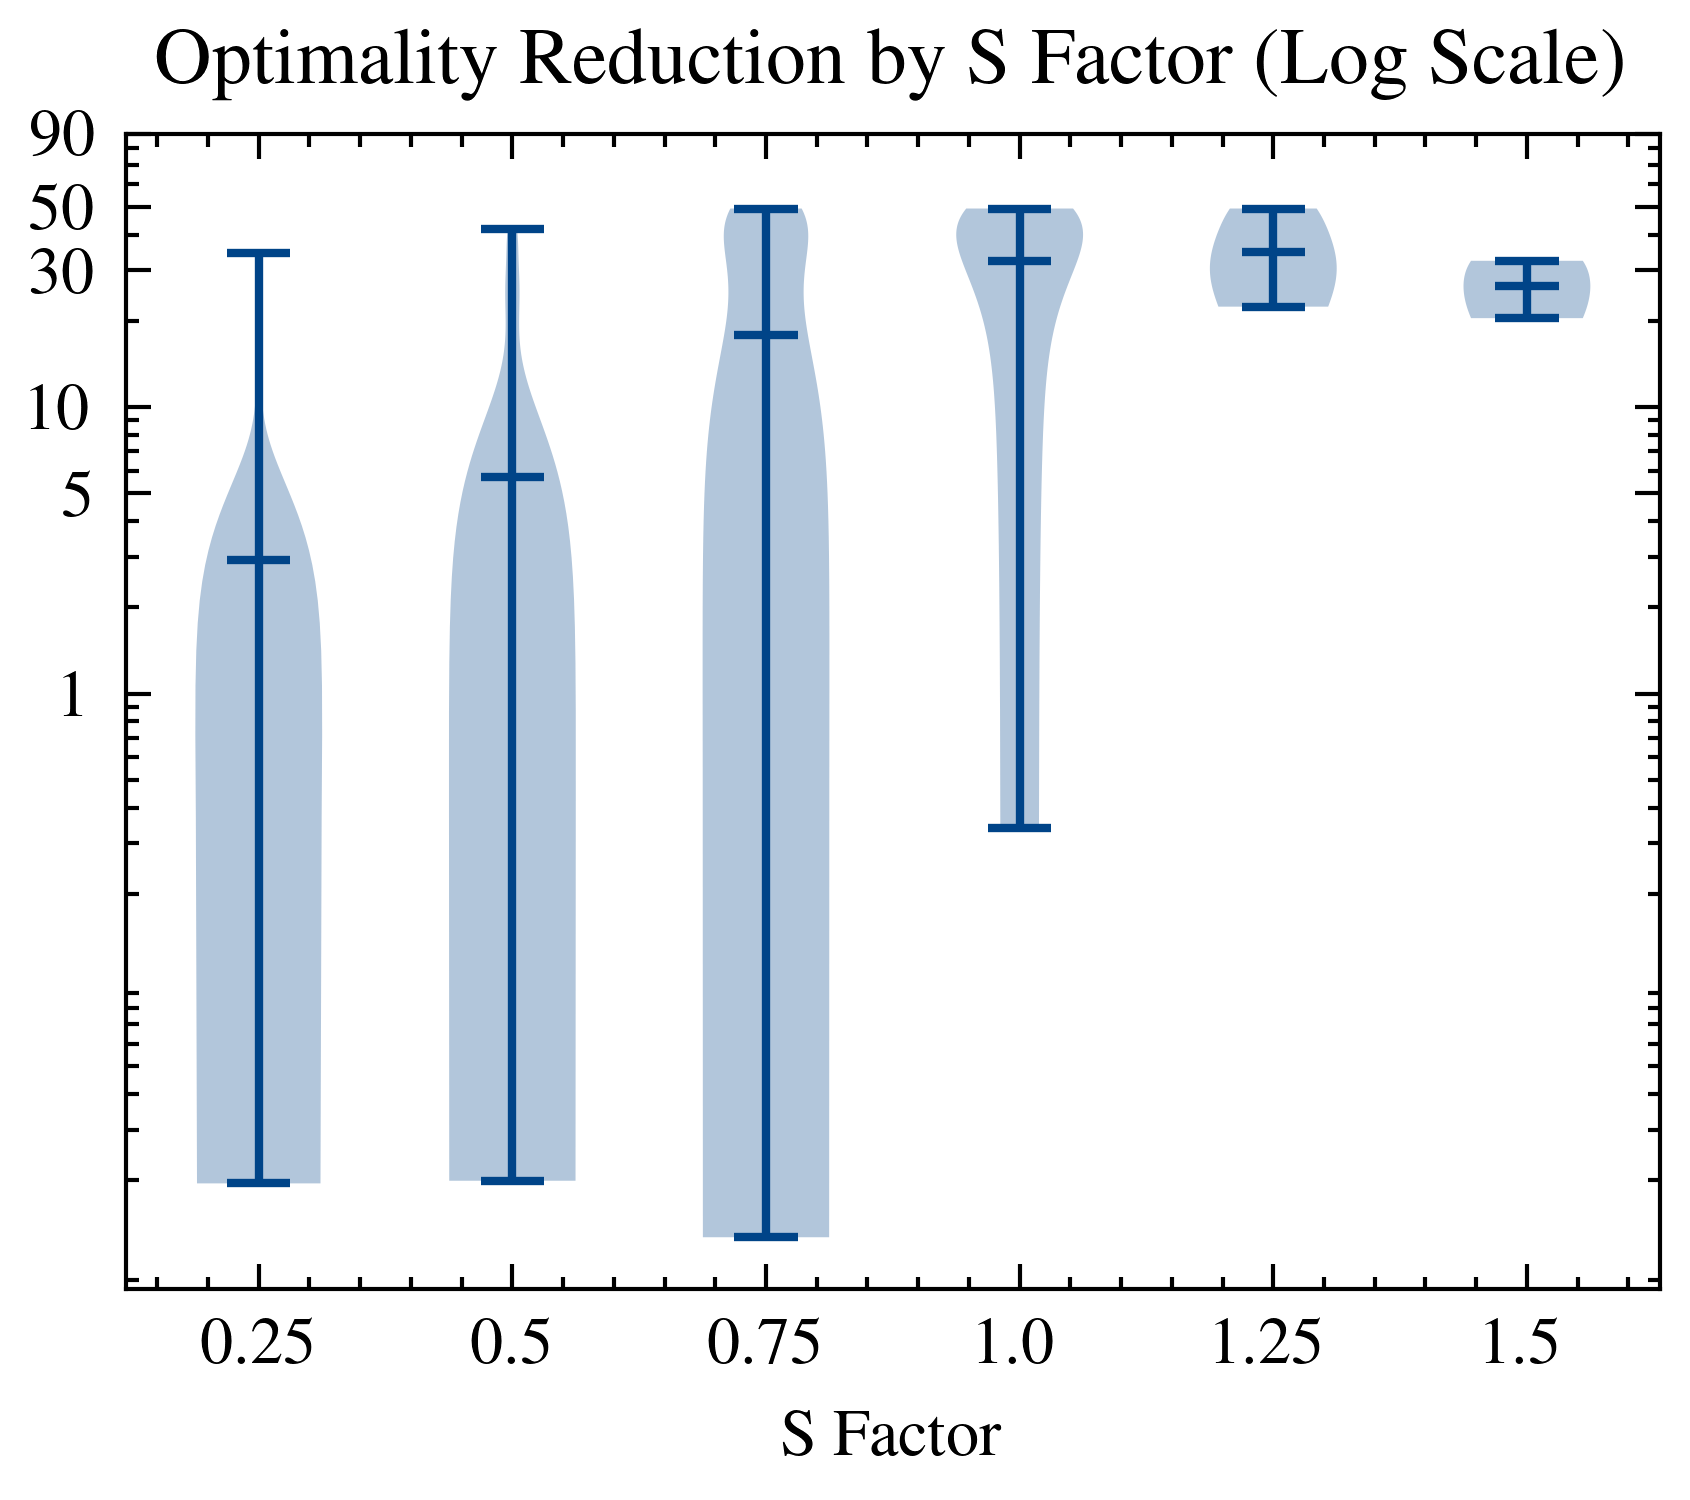

In [81]:
fig, ax = plt.subplots()
vplot = ax.violinplot(
    [df_tsplib[df_tsplib["s"] == s]["optimality_reduction_per_bad_pair"].dropna() for s in S_TEST_VALUES],
    showmeans=True,
)
ax.set_yscale("log")
ax.set_xlabel("S Factor")
ax.set_xticks(ticks=np.arange(1, len(S_TEST_VALUES) + 1), labels=S_TEST_VALUES)
ax.set_title("Optimality Reduction by S Factor (Log Scale)")
ax.set_yticks([0.01, 0.05, 0.1, 0.3, 0.5, 0.9], labels=["1%", "5%", "10%", "30%", "50%", "90%"])

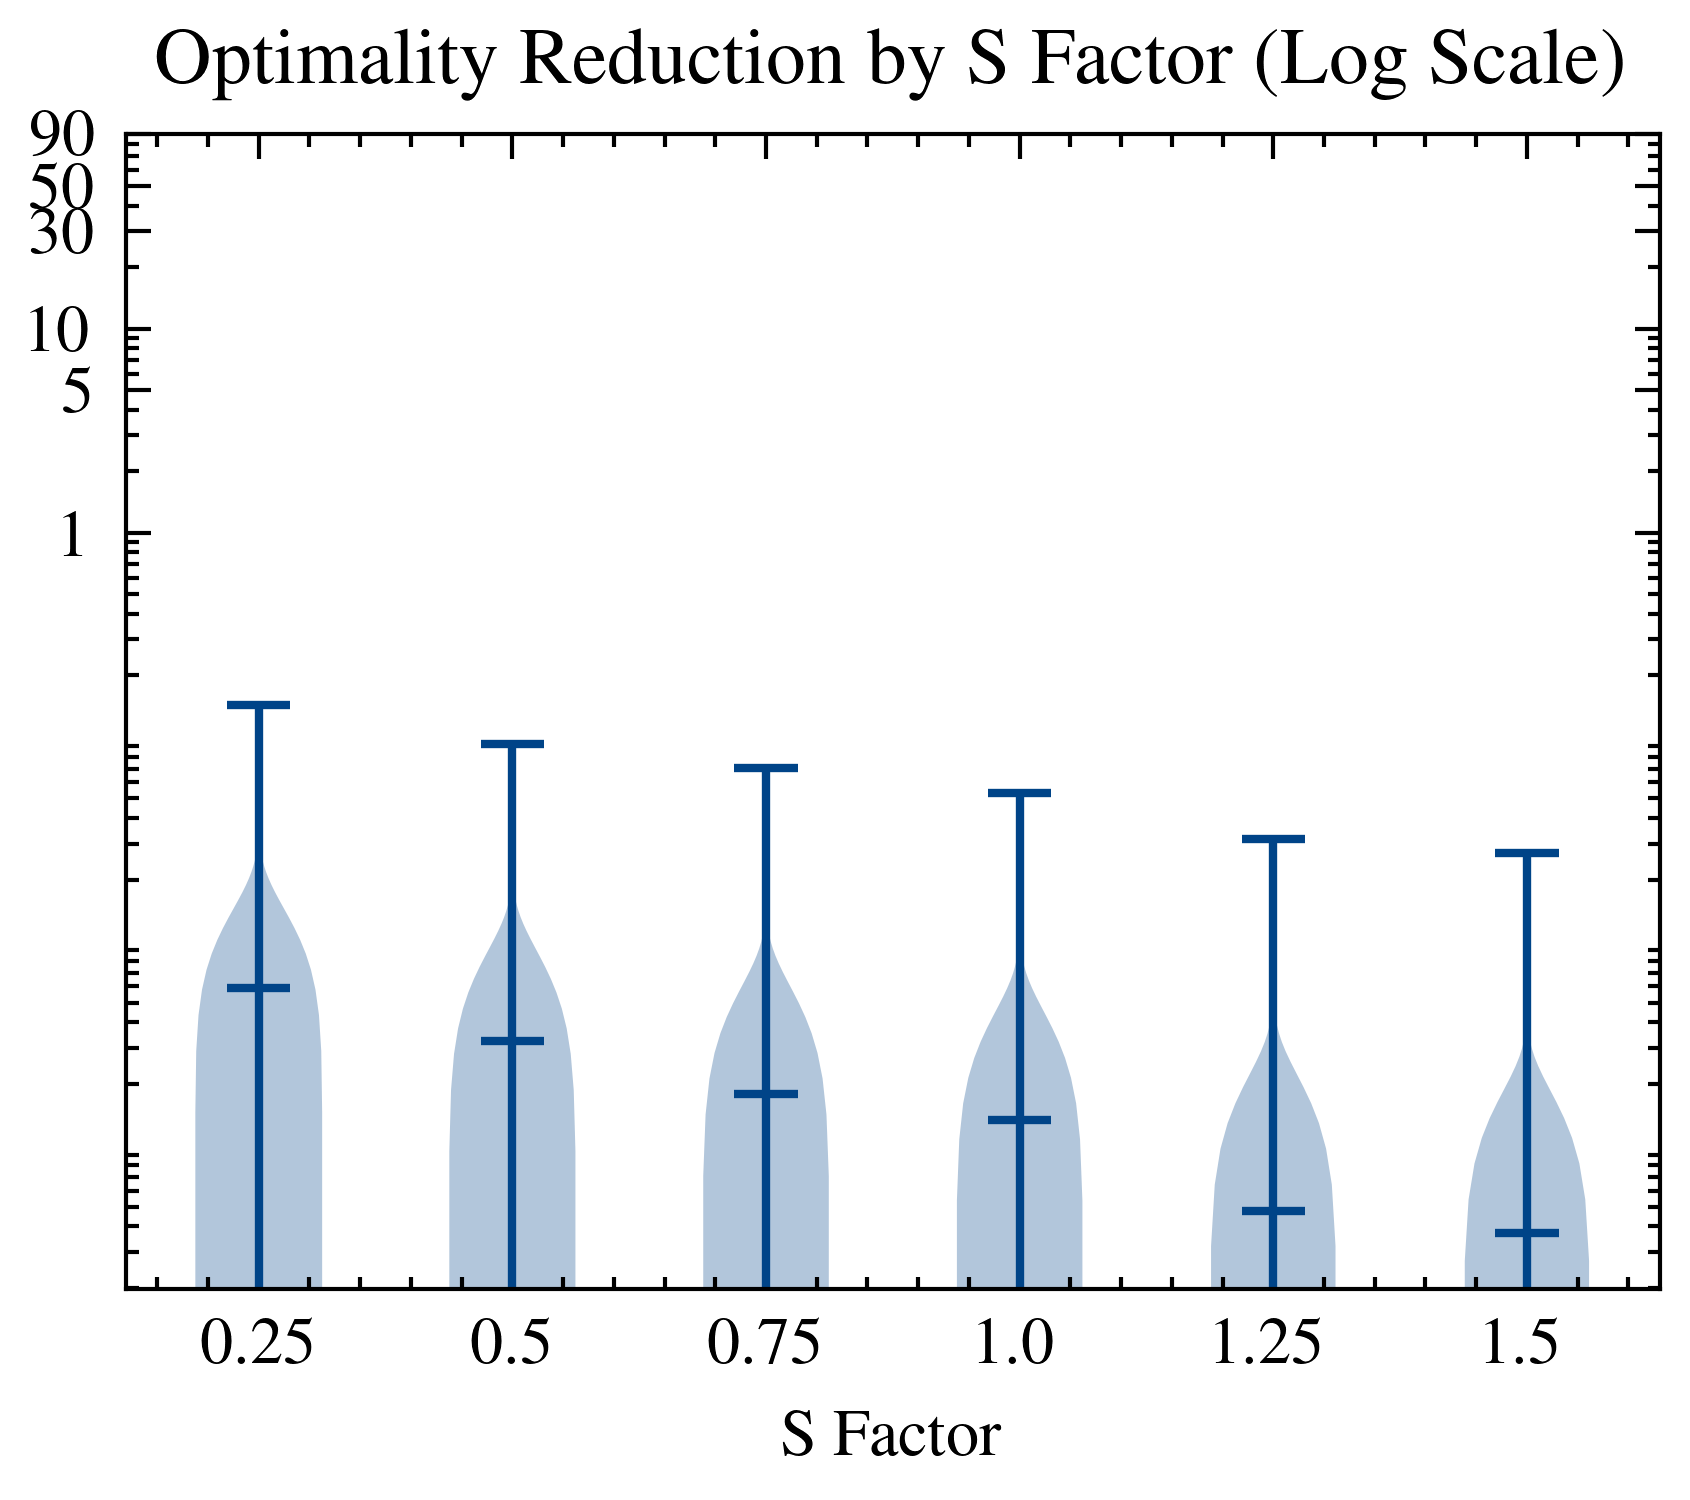

In [82]:
fig, ax = plt.subplots()
vplot = ax.violinplot(
    [df_tsplib[df_tsplib["s"] == s]["optimality_reduction_per_total_pair"].dropna() for s in S_TEST_VALUES],
    showmeans=True,
)
ax.set_yscale("log")
ax.set_xlabel("S Factor")
ax.set_xticks(ticks=np.arange(1, len(S_TEST_VALUES) + 1), labels=S_TEST_VALUES)
ax.set_title("Optimality Reduction by S Factor (Log Scale)")
ax.set_yticks([0.01, 0.05, 0.1, 0.3, 0.5, 0.9], labels=["1%", "5%", "10%", "30%", "50%", "90%"])

reduction_bucket,0-1,1-5,5-10,10-25,25-50,50+
s,,,,,,
0.25,65,6,0,1,3,1
0.50,71,1,0,3,1,0
0.75,71,2,0,2,1,0
1.00,71,2,0,2,1,0
1.25,73,2,0,0,1,0
1.50,74,2,0,0,0,0


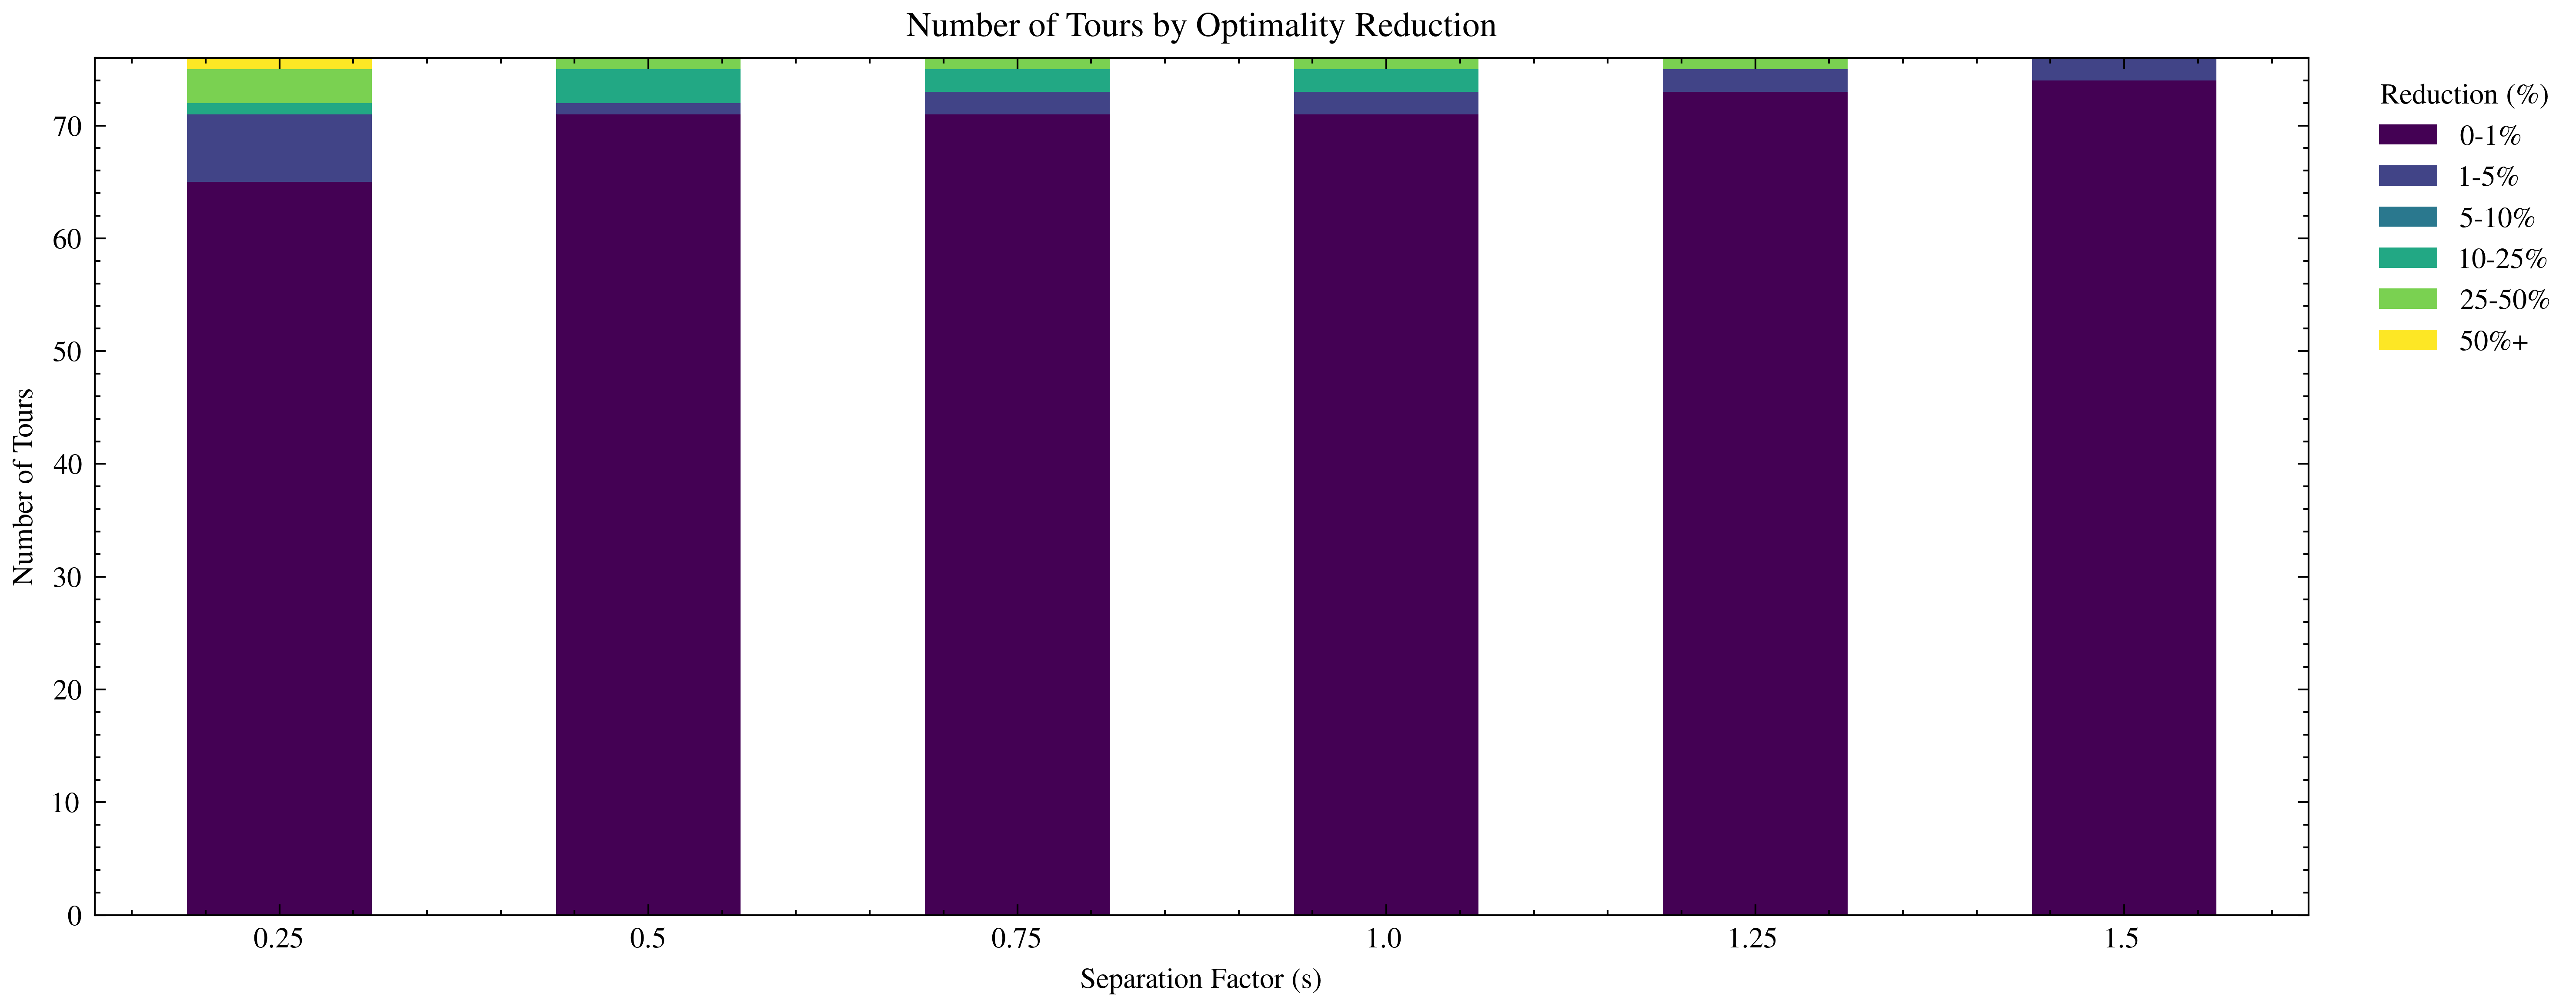

In [87]:
# Bucket optimality reduction (in %) and count tours per separation factor s
plot_df = df_tsplib[["name", "s", "random_optimality_reduction"]].copy()
plot_df["reduction_pct"] = (plot_df["random_optimality_reduction"] * 100).clip(lower=0)

bins = [0, 1, 5, 10, 25, 50, np.inf]
bucket_labels = ["0-1", "1-5", "5-10", "10-25", "25-50", "50+"]

plot_df["reduction_bucket"] = pd.cut(
    plot_df["reduction_pct"],
    bins=bins,
    labels=bucket_labels,
    include_lowest=True,
    right=False
)

count_table = (
    plot_df.groupby(["s", "reduction_bucket"], observed=False)["name"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=bucket_labels, fill_value=0)
)

ax = count_table.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="viridis", rot=0)
ax.set_xlabel("Separation Factor (s)")
ax.set_ylabel("Number of Tours")
ax.set_title("Number of Tours by Optimality Reduction")

# TeX-safe percent labels for legend
legend_labels = ["0-1\\%", "1-5\\%", "5-10\\%", "10-25\\%", "25-50\\%", "50\\%+"]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, title="Reduction (\\%)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
count_table